# Parte 1 - SCIKIT-LEARN.


In [88]:
#%pip install --upgrade pip                   #Gemini me sugeriu para corrigir o erro, porque o colab não estava instalando
#%pip install --upgrade setuptools wheel      # não deu certo, pq demanda uma versão mais antiga do python igual.
#%pip install numpy==1.18.5 scipy==1.4.1
#%pip install --upgrade scikit-learn==0.23.0

# o curso pede que use essa versão do scikit-learn em específico em específico

# paciência, vamos assim mesmo.

Data ----> Model -----> Predictions<br>

we start with some data, give it to a model, the model will learn from it, and then we will be able to make predictions<br>

we split the dataset into 2 parts:<br>
X: represents what i'm using to make a prediction<br>
Y: contains the prediction that im interested in making
<br><br>
Example:<br>
X - information about houses<br>
Y - house prices

In [89]:
#from sklearn.datasets import load_boston                # não deu certo. Talvez essa seja a razão pra usar uma versão antiga do scikit-learn.

# o erro que dá aqui sugere que esse dataset das Boston housing prices tem 'etical problems'.
# Mas pelo menos ele me explica como abrir o dataset. Vou ter que dar essa volta antes de continuar.

In [90]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# só pra ficar claro: essa primeira parte do código sugerido lê a tabela toda.
# só que ela está construída de uma forma 'difícil' no site, porque em vez de estarem todos os dados tabelados bonitinho,
# eles estão 'quebrados' (abra o link e olhe!)

# então, a linha seguinte chama o numpy e faz uma manipulação com as linhas pares e ímpares.

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_227/1306281072.py:5: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [91]:
raw_df

,0,1,2,3,4,5,6,7,8,9,10
0,0.00632,18.00,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3
1,396.90000,4.98,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.02731,0.00,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8
3,396.90000,9.14,21.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.02729,0.00,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8
...,...,...,...,...,...,...,...,...,...,...,...
1007,396.90000,5.64,23.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1008,0.10959,0.00,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0
1009,393.45000,6.48,22.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1010,0.04741,0.00,11.93,0.0,0.573,6.030,80.8,2.5050,1.0,273.0,21.0


In [92]:
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])

# nessa linha acima ele pega todas as linhas pares da tabela e coloca ao lado das linhas ímpares, corrigindo a tabela.

target = raw_df.values[1::2, 2]

# por fim, ele define a última linha (que está nas linhas ímpares) como meu 'target'.

# essa distinção entre 'data' e 'target' é a distinção entre X e Y do scikit-learn.

In [93]:
print(data)
print(target)

# são os dois arrays que ele dá no 'return_X_y=True', que ele atribui a X e y justamente

[[6.3200e-03 1.8000e+01 2.3100e+00 ... 1.5300e+01 3.9690e+02 4.9800e+00]
 [2.7310e-02 0.0000e+00 7.0700e+00 ... 1.7800e+01 3.9690e+02 9.1400e+00]
 [2.7290e-02 0.0000e+00 7.0700e+00 ... 1.7800e+01 3.9283e+02 4.0300e+00]
 ...
 [6.0760e-02 0.0000e+00 1.1930e+01 ... 2.1000e+01 3.9690e+02 5.6400e+00]
 [1.0959e-01 0.0000e+00 1.1930e+01 ... 2.1000e+01 3.9345e+02 6.4800e+00]
 [4.7410e-02 0.0000e+00 1.1930e+01 ... 2.1000e+01 3.9690e+02 7.8800e+00]]
[24.  21.6 34.7 33.4 36.2 28.7 22.9 27.1 16.5 18.9 15.  18.9 21.7 20.4
 18.2 19.9 23.1 17.5 20.2 18.2 13.6 19.6 15.2 14.5 15.6 13.9 16.6 14.8
 18.4 21.  12.7 14.5 13.2 13.1 13.5 18.9 20.  21.  24.7 30.8 34.9 26.6
 25.3 24.7 21.2 19.3 20.  16.6 14.4 19.4 19.7 20.5 25.  23.4 18.9 35.4
 24.7 31.6 23.3 19.6 18.7 16.  22.2 25.  33.  23.5 19.4 22.  17.4 20.9
 24.2 21.7 22.8 23.4 24.1 21.4 20.  20.8 21.2 20.3 28.  23.9 24.8 22.9
 23.9 26.6 22.5 22.2 23.6 28.7 22.6 22.  22.9 25.  20.6 28.4 21.4 38.7
 43.8 33.2 27.5 26.5 18.6 19.3 20.1 19.5 19.5 20.4 19.8 19.

In [94]:
X = data
y = target

In [95]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

# aqui, chamei dois modelos diferentes. O ponto desta parte é mostrar que o scikit-learn funciona com o mesmo código,
# independentemente do modelo que estou usando.

# 1) crio o modelo atribuindo a uma variável;
# 2) faço .fit()
# 3) faço .predict()

# is dois modelos dão valores diferentes (por óbvio, se funcionam diferente), mas o processo do scikit-learn é o mesmo.

In [96]:
mod1 = KNeighborsRegressor()
mod2 = LinearRegression()

In [97]:
mod1.fit(X,y)

KNeighborsRegressor()

In [98]:
mod2.fit(X,y)

LinearRegression()

In [99]:
pred1 = mod1.predict(X)

In [100]:
pred2 = mod2.predict(X)

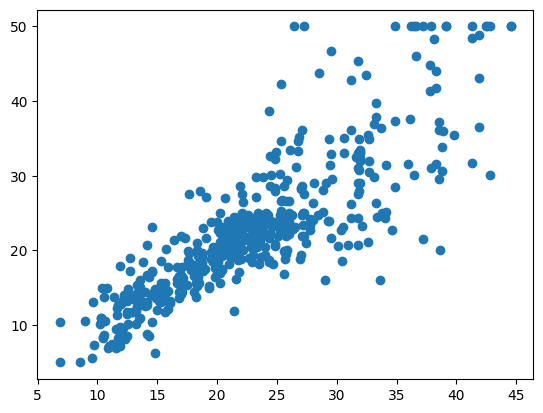

In [101]:
import matplotlib.pyplot as plt    # no vídeo ele importou o pylab, mas pelo que vi no google, pylab dá problema hoje em dia

plt.scatter(pred1, y)
# comparando valores reais de y com valores previstos de y. Idealmente, se esperaria uma reta, sugerindo que
# minhas previsões estão perfeitas. Mas obviamente não vivemos no mundo ideal

No caso de alguns modelos, tal qual o KNN, diferentes variáveis com diferentes escalas precisam primeiro serem 'normalizadas'. Preciso colocá-las todas numa escala, a fim de que variáveis com valores muito altos ou muito baixos não afetem o modelo de forma assimétrica.
<br><br>
Por isso, o esquema começa a se tornar diferente:

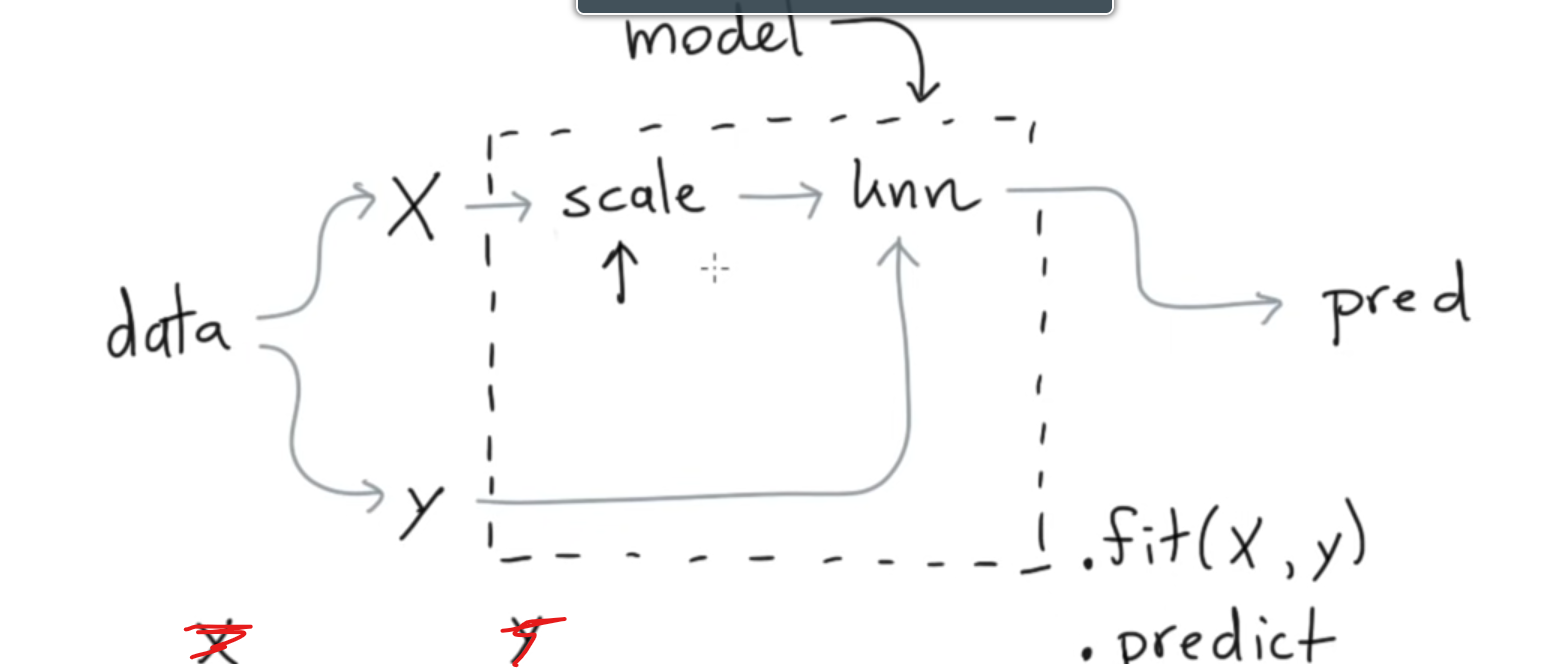

In [102]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# no curso, ele volta nas células anteriores e reedita o código.
# aqui, prefiro refazer o processo aqui embaixo, pra não perder o começo

#mod = KNeighborsRegressor().fit(X,y)

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor())
])

In [103]:
pipe.fit(X, y)

# dei fit no pipeline inteiro. Primeiro ele faz o scale e depois o KNN

Pipeline(steps=[('scale', StandardScaler()), ('model', KNeighborsRegressor())])

In [104]:
pred = pipe.predict(X)   # LEMBRAR! antes eu fazia 'mod.predict(X)', porque fazia fit direto no modelo
                         # agora eu preciso pedir o predict no Pipeline porque dei fit nele inteiro
                         #
                         # nesse caso, não preciso dar fit no 'mod' (inclusive comentei a linha duas células acima pra verificar)

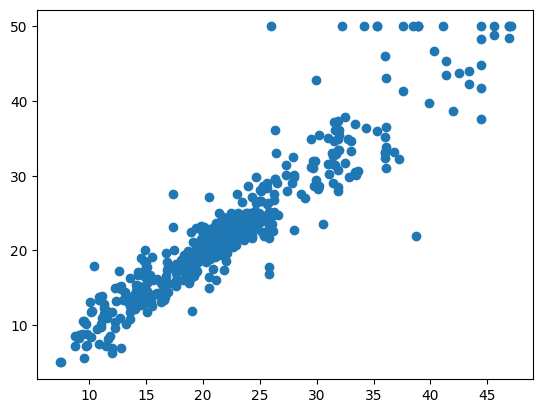

In [105]:
plt.scatter(pred,y)

In [106]:
# KNeighborsRegressor() usa 'n_neighbors=5' por default. Só que, se alterarmos pra 'n_neighbors=1',
# verificamos que há um problema no nosso código:
# o KNN usa o próprio ponto dado como um dos 'neighbors, o que faz com que ele preveja 'perfeitamente' quando n_neighbors=1.
#
# Esse é um problema de overfit (aparentemente).

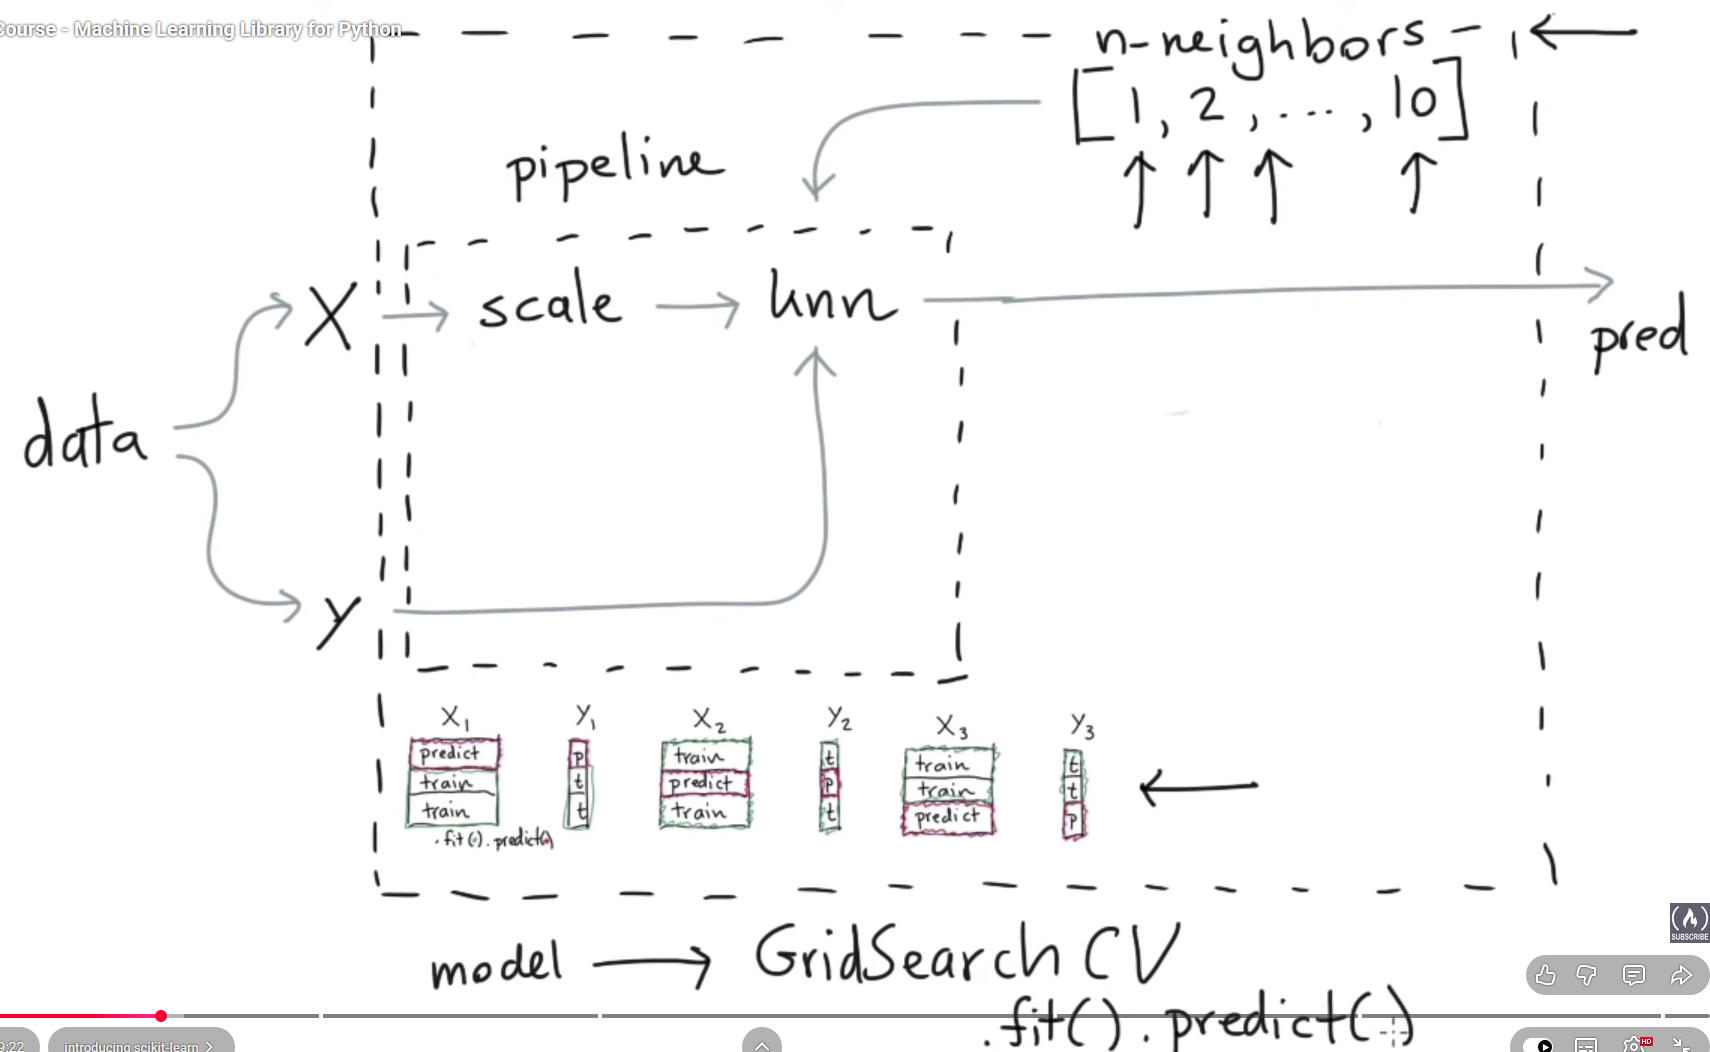

In [107]:
# A ideia nessa imagem acima é a seguinte:
#
# 1) eu não sei quantos 'nearest neighbors' otimiza meu processo;
# 2) e também preciso segmentar meus dados de forma que uma parte seja pra treinar o modelo e outra pra fazer previsões,
#    caso contrário, meu modelo vai sempre 'acertar' as previsões pra esses mesmos dados.
#
# Então o plano é segmentar meus dados de formas diversas e testar pra diferentes quantidades de nearest neighbors.
#
# pra isso, existe esse GridSearchCV. Ele também tem métodos .fit() e um .predict().

In [108]:
# you can give this GridSearch a pipeline and a grid (the number of neighbors),
# and internally it will perform crossvalidation (the segmentation in 'predict' and 'train' slices in different Xs and Ys)

In [109]:
# então, chamando a biblioteca e fazendo novamente:

from sklearn.model_selection import GridSearchCV

X = data
y = target

pipe = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsRegressor())
])

pipe.get_params()

# a saída desse método .get_params() são todos os parametros dos objetos estimadores no scikit-learn.
# NOTAR!: as variáveis dentro dele estão divididas entre 1) as internas, 2) as do 'scale' e 3) as do model.
# queremos a variável do model chamada 'model__n_neighbors'.
# na aula, o professor comentou o get_params() depois de pegar a variável. Eu vou deixar a saída aqui.

{'memory': None,
 'steps': [('scale', StandardScaler()), ('model', KNeighborsRegressor())],
 'transform_input': None,
 'verbose': False,
 'scale': StandardScaler(),
 'model': KNeighborsRegressor(),
 'scale__copy': True,
 'scale__with_mean': True,
 'scale__with_std': True,
 'model__algorithm': 'auto',
 'model__leaf_size': 30,
 'model__metric': 'minkowski',
 'model__metric_params': None,
 'model__n_jobs': None,
 'model__n_neighbors': 5,
 'model__p': 2,
 'model__weights': 'uniform'}

In [110]:
mod = GridSearchCV(estimator=pipe,
                   param_grid={'model__n_neighbors': [1,2,3,4,5,6,7,8,9,10]},
                   cv=3)

# no param_grid a gente pegou a variável 'model__n_neighbors', mas eu poderia ter dado uma lista de valores pra
# qualquer uma das variáveis listadas no get_params.
#
# PERCEBER! cv = 3 significa que, conforme a imagem, eu criei 3 conjuntos de Xi e yi,
# onde duas partes são para treino e uma para predict. Significa que posso fazer com n números também.

In [111]:
mod.fit(X, y);
mod.cv_results_     # esse cv_results_ tira uma série de estatísticas a partir dos crossvalidations e n_neighbors que eu defini
                    # o resultado vem num dicionário difícil. Mas se eu der o resultado pra um dataframe do Pandas fica bãozão

{'mean_fit_time': array([0.00683212, 0.00298119, 0.00298071, 0.0078121 , 0.00569471,
        0.00857226, 0.01146468, 0.00387096, 0.00349434, 0.003057  ]),
 'std_fit_time': array([5.37593121e-03, 4.23567230e-05, 5.82145071e-05, 9.90306257e-04,
        2.53421202e-03, 9.26062251e-04, 1.37599448e-04, 9.44071604e-04,
        6.28960724e-04, 6.22477991e-05]),
 'mean_score_time': array([0.00535186, 0.00399717, 0.00398691, 0.00954747, 0.00763496,
        0.01125511, 0.01292459, 0.00458598, 0.00495458, 0.00748754]),
 'std_score_time': array([0.00164831, 0.00022347, 0.00018776, 0.00181353, 0.00253737,
        0.00215593, 0.00313568, 0.00050051, 0.00070846, 0.00454724]),
 'param_model__n_neighbors': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value=999999),
 'params': [{'model__n_neighbors': 1},
  {'model__n_neighbors': 2},
  {'model__n_neighbors': 3},
  {'model__n_n

In [112]:
pd.DataFrame(mod.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.006832,0.005376,0.005352,0.001648,1,{'model__n_neighbors': 1},0.226933,0.432998,0.127635,0.262522,0.127179,10
1,0.002981,0.000042,0.003997,0.000223,2,{'model__n_neighbors': 2},0.358216,0.409229,0.172294,0.313246,0.101821,9
2,0.002981,0.000058,0.003987,0.000188,3,{'model__n_neighbors': 3},0.413515,0.476651,0.318534,0.402900,0.064986,1
3,0.007812,0.000990,0.009547,0.001814,4,{'model__n_neighbors': 4},0.475349,0.402495,0.273014,0.383619,0.083675,7
4,0.005695,0.002534,0.007635,0.002537,5,{'model__n_neighbors': 5},0.512318,0.347951,0.262590,0.374286,0.103638,8
5,0.008572,0.000926,0.011255,0.002156,6,{'model__n_neighbors': 6},0.533611,0.389504,0.248482,0.390532,0.116406,6
6,0.011465,0.000138,0.012925,0.003136,7,{'model__n_neighbors': 7},0.544782,0.385199,0.243668,0.391216,0.123003,5
7,0.003871,0.000944,0.004586,0.000501,8,{'model__n_neighbors': 8},0.589644,0.394650,0.209714,0.398003,0.155124,2
8,0.003494,0.000629,0.004955,0.000708,9,{'model__n_neighbors': 9},0.590352,0.407556,0.185253,0.394387,0.165643,3
9,0.003057,0.000062,0.007488,0.004547,10,{'model__n_neighbors': 10},0.616510,0.395077,0.164023,0.391870,0.184741,4


In [113]:
# nesse DataFrame, há um ranking na última linha, e aparentemente o melhor número de neighbors seria 3.
# ele não entra na discussão do porquê é isso. Provavelmente teria que considerar os diferentes splits, e entender como ele fez os scores.
#
#
#             Mas o que é importante aí? (ou, o que ele estava tentando mostrar?)
#
# O uso 'corriqueiro' do scikit-learn vai manter essa configuração, esse 'modelo':
# - um pipeline com certos elementos, tal qual 'scale' e model'
# - o modelo com um GridSearchCV.
#
#

In [114]:
# A última etapa da aula (29min a frente) dá uma olhada nos dados do load_Boston dataset. Eu não pude abrir como ele abriu pq esse dataset não está mais disponível nesta versão
# e é justamente por isso que ele acabou pegando uma versão antiga do scikit-learn.
#
# ele explica que eu tenho que olhar pros dados, e que entender os dados (e se eles são adequados) é principal em relação a entender scikit-learn.
#

# Parte 2 - Preprocessing.

O processo no Scikit-learn muito comumente envolve efetuar alguma transformação nos dados usados, então essa etapa vai tratar especificamente destas transformações.<br>

Essa parte é aparentemente independente da parte 1, então eu vou chamar todas as bibliotecas novamente, conforme forem aparecendo (por uma questão de aprendizado e 'ordem').

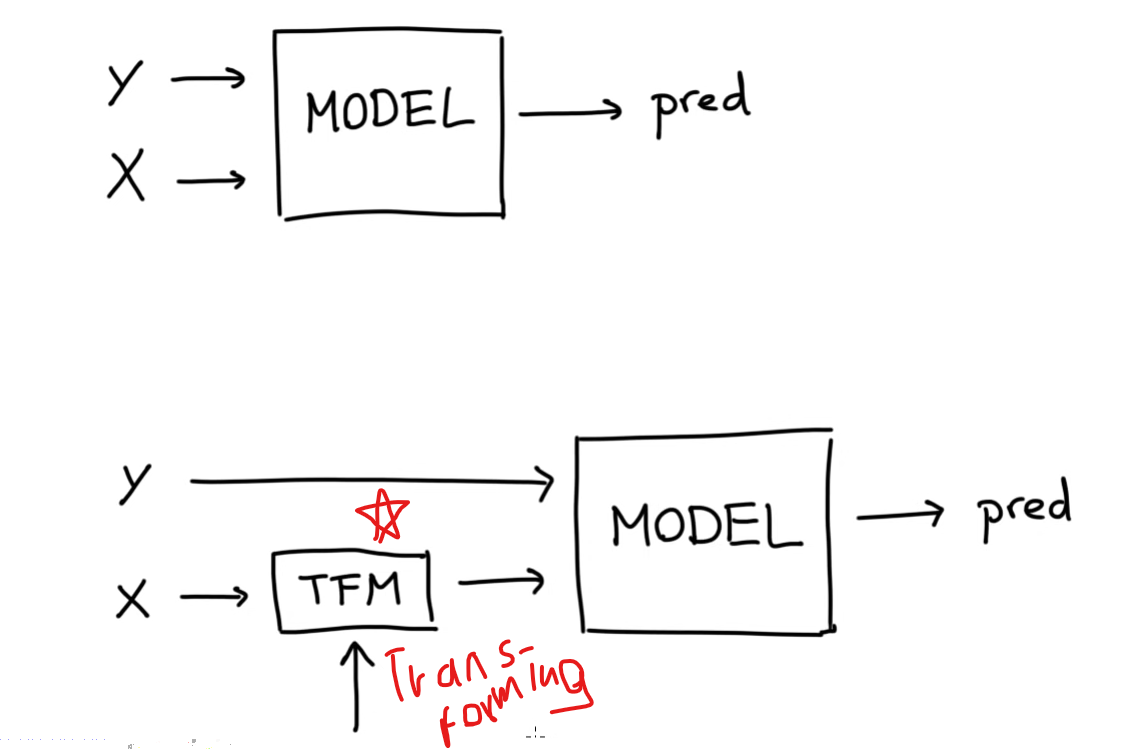

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt    # novamente, ele chamou pylab

url ='https://raw.githubusercontent.com/koaning/calm-notebooks/refs/heads/master/scikit-prep/drawndata1.csv'

df = pd.read_csv(url)

# ele tinha o dataset na máquina, mas buscando nos links do youtube achei o link.

In [116]:
df.head()

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a
3,262.004361,284.251445,a
4,185.243183,308.187571,a


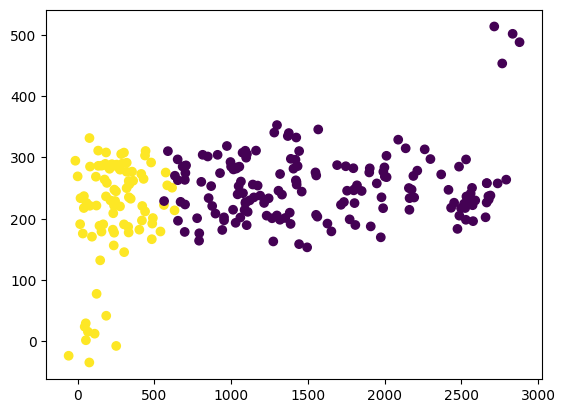

In [117]:
X = df[['x', 'y']].values      # só aceita plotar se eu usar '.values' aqui. Não sei por que, mas é algo a ficar esperto. Talvez o matplotlib tenha alguma dificuldade com valores no pandas.
y = df['z'] == "a"

plt.scatter(X[:,0],X[:,1], c=y);

In [118]:
# "a large chunk of your pre-processing in this case is gonna revolve around SCALING.
# we wanna rescale this data such as theres still information on there, but its just numerically a bit more stable
# because the X and Y axes are just a little bit more in line with each other".

# a standard way of doing this is using the StandardScaler.

it calculate the mean and the variance and make
$$ \frac { x - mean(x) }{\sqrt{var} } $$
then you gonna have something that revolves around zero and have the variance kept at bay

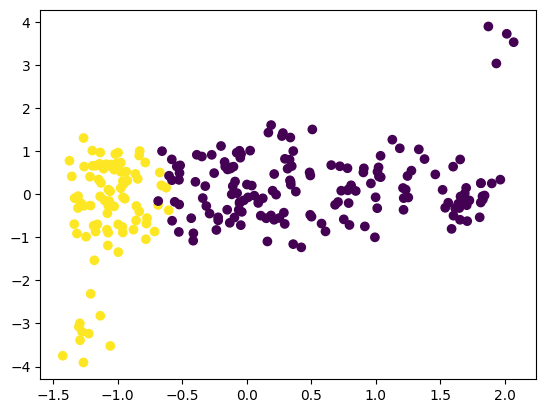

In [119]:
from sklearn.preprocessing import StandardScaler

X_new = StandardScaler().fit_transform(X)      # criar um novo transformed dataset, que é o dataset X transformado

plt.scatter(X_new[:,0],X_new[:,1], c=y);

# os eixos X e Y estão numa escala mais próxima, mas ainda não é uma escala perfeita.
# em especial, o eixo Y tem tamanho 8 e o eixo X tamanho 3,5
#
# além disso, ainda temos os outliers.

In [120]:
# O professor introduziu a questão de como lidar com os outliers.
#
# a ideia é: tirar a média não é uma boa, mas sim dividir a amostra em quantis.
#           **ATENTAR: a ideia é dividir em quaNtis, não em quaRtis. **
#
# Na imagem abaixo, ele dividiu nos 3 primeiros quartis (1o quartil, 2o quartil = mediana, 3o quartil)
# e também marcou o quantil 99, onde 99% da amostra está à esquerda e 1% à direita.
#
# daí, o objetivo é 'escalar' a partir desses quantis.

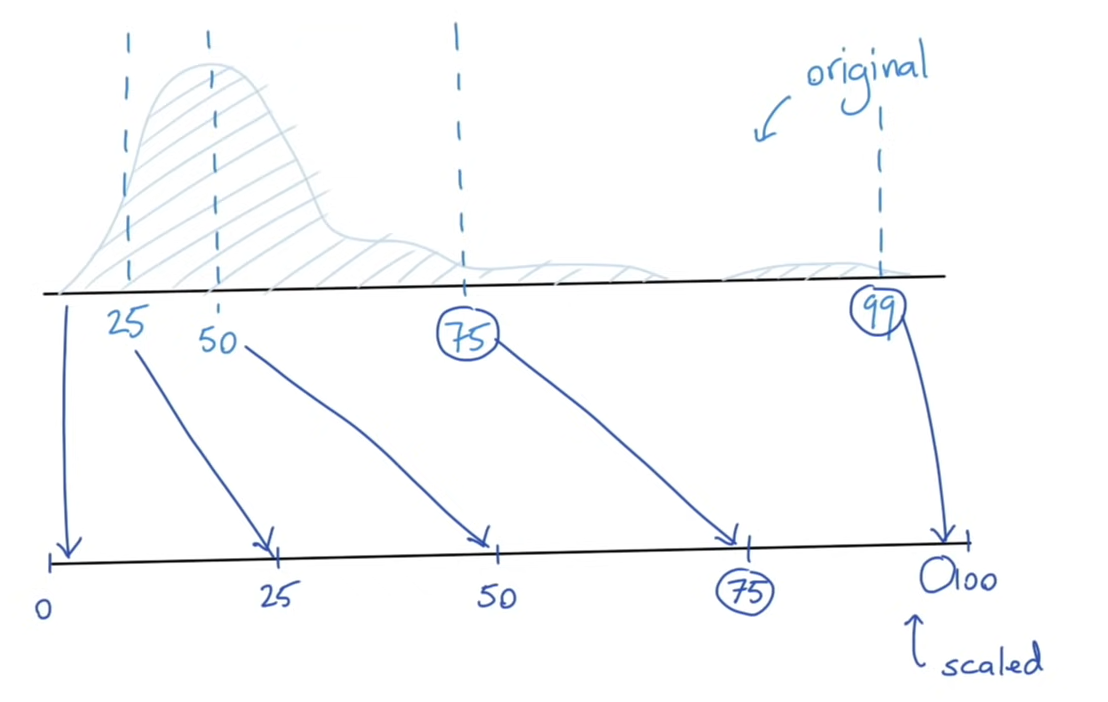

{'copy': True,
 'ignore_implicit_zeros': False,
 'n_quantiles': 1000,
 'output_distribution': 'uniform',
 'random_state': None,
 'subsample': 10000}

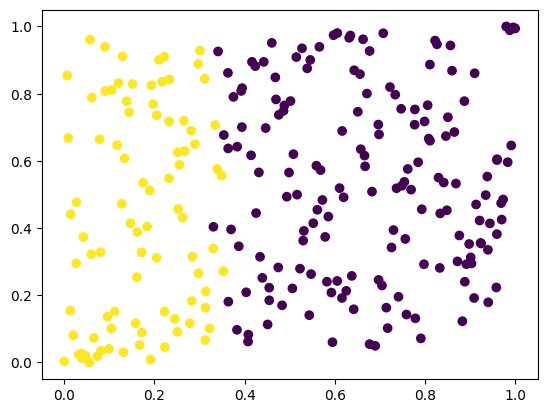

In [121]:
from sklearn.preprocessing import QuantileTransformer

X_new = QuantileTransformer(n_quantiles=100).fit_transform(X)    # mesmo código da célula com o StandardScaler(), pra ver a diferença

plt.scatter(X_new[:,0],X_new[:,1], c=y);      # dá um WARNING: o scikit-learn por padrão define 1000 quantis, mas só tenho 252 dados na amostra.
                                              # por isso, ele definiu o n_quantiles=100 manualmente. Abaixo, eu chamei o get_params() do QuantileTransformer
                                              # pra ver o que mais tem nele.

QuantileTransformer().get_params()

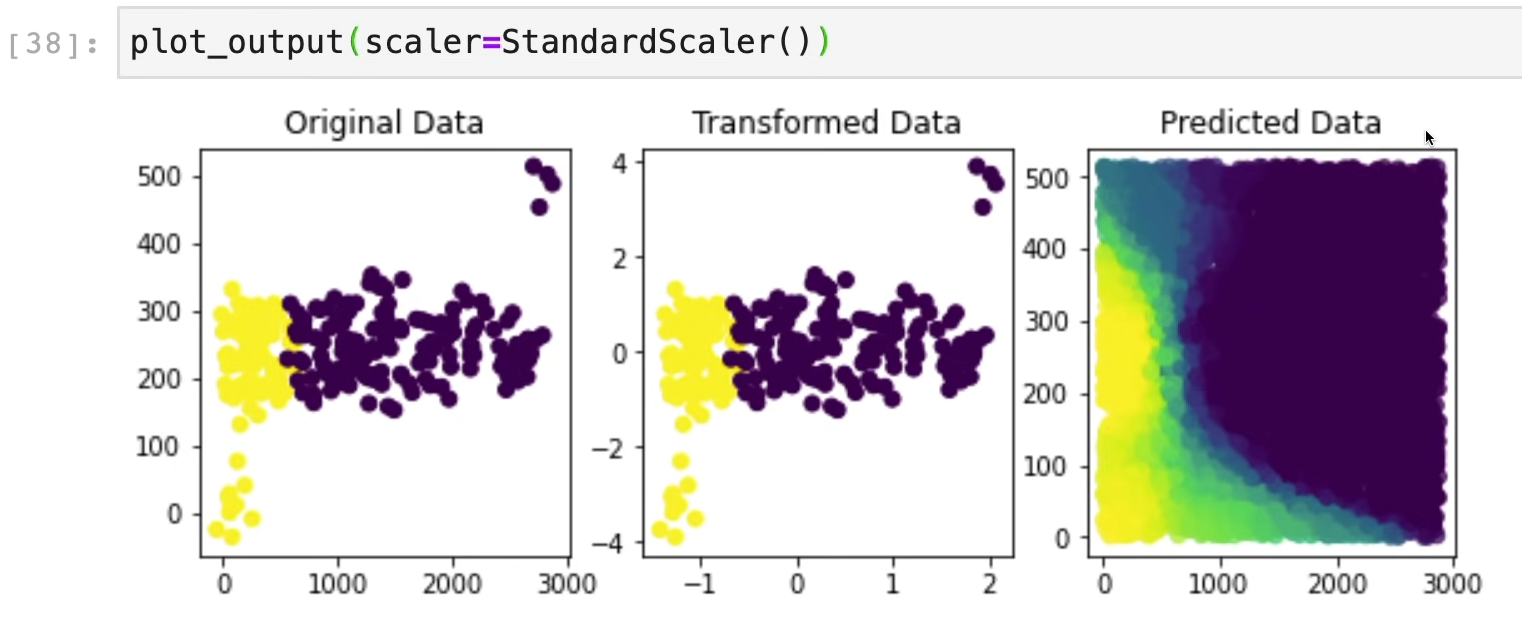

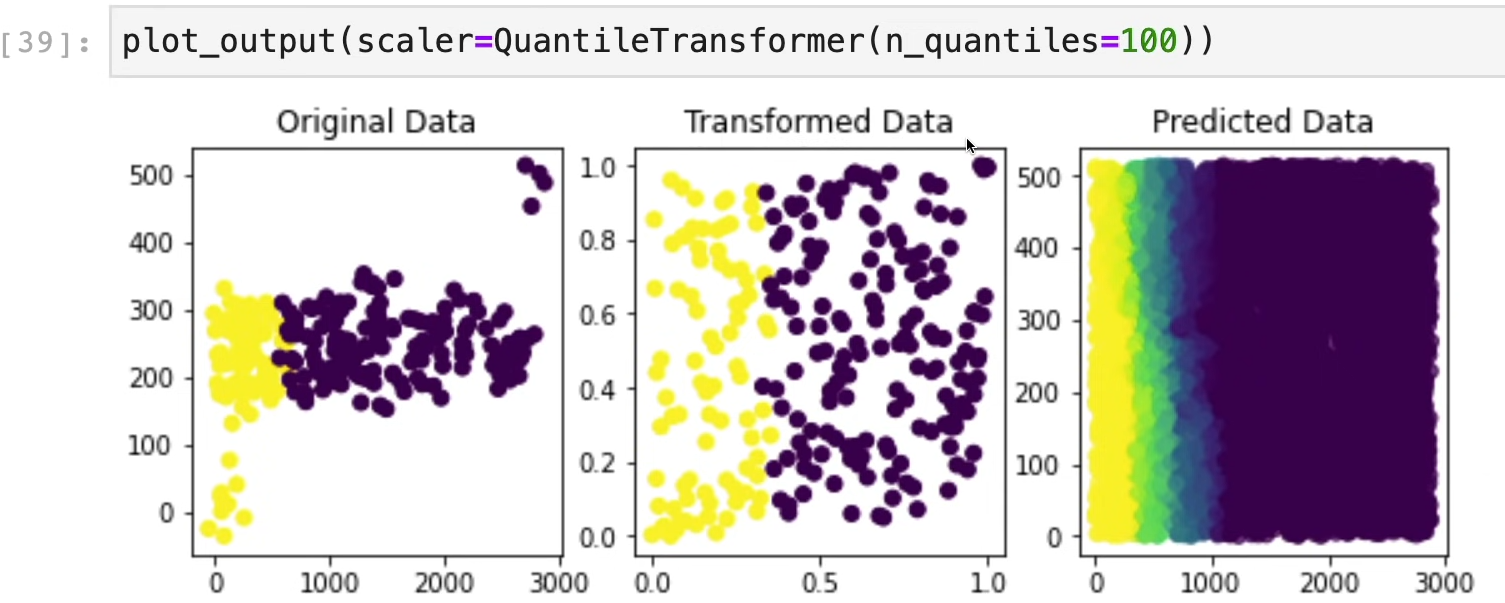

In [122]:
# a função plot_output das imagens acima foi definida pelo professor do freeCodeCamp mas ele não mostrou onde nem quando.
# a intenção é só mostrar como os dados previstos ficam diferentes.
#
# provavelmente ele fez um grid no numpy com 550x3000 pontos, considerando o espaço dos dados originais...
# que foi o que o professor da Alura fez no curso de classificação.

## um segundo Dataset

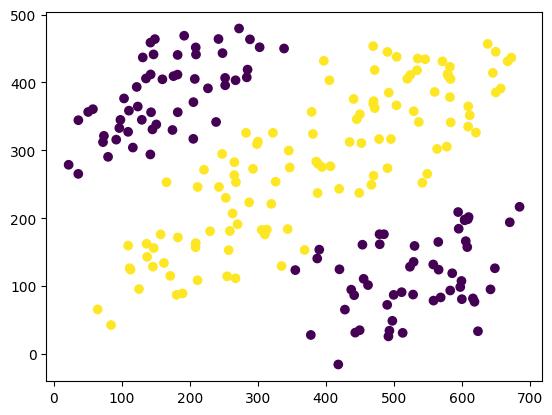

In [123]:
# agora veremos um segundo dataset. Ele chamou direto no jupiter, mas é do link abaixo.

url = "https://raw.githubusercontent.com/koaning/calm-notebooks/refs/heads/master/scikit-prep/drawndata2.csv"

df = pd.read_csv(url)
X = df[['x','y']].values
y = df['z'] == 'a'
plt.scatter(X[:,0], X[:,1],c=y);

# esse dataset de classificação não é 'linearmente separável'. Não tem como traçar uma linha que separar os valores 'a' dos valores 'b'

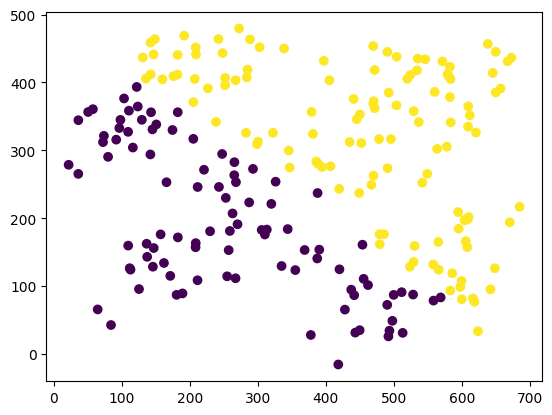

In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scale", QuantileTransformer(n_quantiles = 100)),
    ("model", LogisticRegression())                     # pipeline com a LogisticRegression pra classificação.
                                                        # não vai fazer um bom serviço porque não consigo traçar uma linha
])

pred = pipe.fit(X,y).predict(X)             # fit e predict dá pra fazer juntos que nem aqui
plt.scatter(X[:,0], X[:,1],c=pred);         # plotei a classificação do predict pra comparar com o gráfico de cima (que é a classificação correta)
                                            # dá pra ver que a tá nada ver

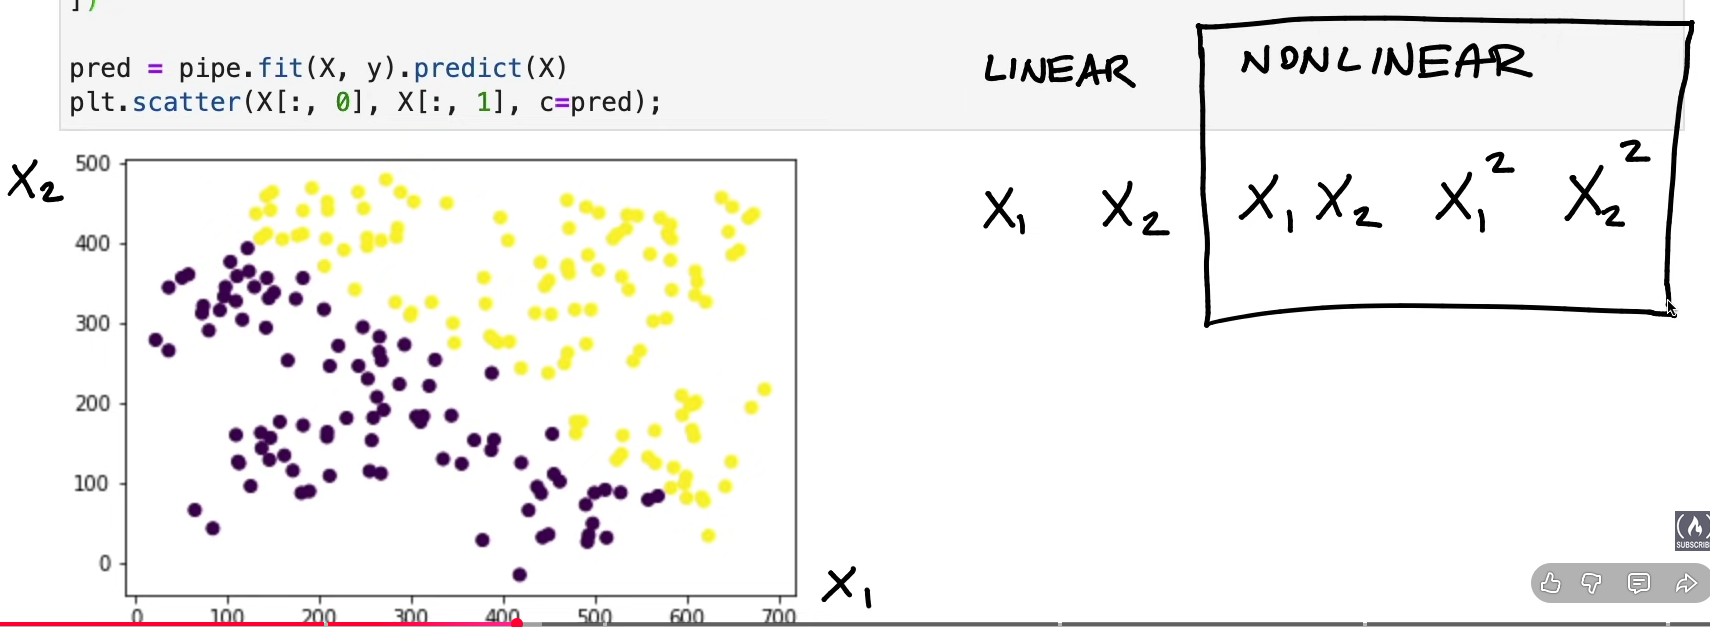

In [125]:
# o argumento aqui é considerar que por enquanto estamos considerando apenas variáveis lineares,
# porém, se multiplicarmos as variáveis (uma pela outra, ou cada uma ao quadrado),
# pode ser que meu modelo faça uma previsão melhor.
#
# O modelo permanece o mesmo, uma regressão logística ainda. O que muda é o preprocessamento.


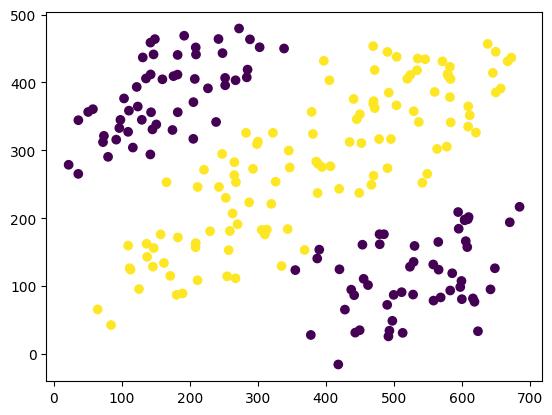

In [126]:
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline([
    ("scale", PolynomialFeatures()),   # por default, ele transforma uma matriz [a,b] em uma [1,a,b,a^2,ab,b^2], portanto, 'degree=2'. Mas eu posso aumentar o grau
    ("model", LogisticRegression())                     # LogisticRegression permanece.
])

pred = pipe.fit(X,y).predict(X)
plt.scatter(X[:,0], X[:,1],c=pred);

# mesmo processo. Mas agora o predict teve grau de praticamente acerto 100% -- granted que eu to usando os dados de treino pra previsão, ou seja, tem uma roubadinha.
# mas a inclusão de elementos não-lineares deu uma grande melhora no modelo (tornou possível, na verdade).

## DADOS NÃO NUMÉRICOS -- OneHotEncoder

In [127]:
#       So far, estamos usando dados numéricos. Mas e se nossos dados são qualitativos?


arr = np.array(["low","low","high","medium"]).reshape(-1,1)      # o método reshape no numpy recebe o parâmetro pra linhas e o pra colunas.
arr                                                              # se tu usar '-1' nas linhas, ele define o número de linhas automaticamente a partir dos dados e da informação das colunas
                                                                 # o inverso também é possível (usar -1 nas colunas e só definir quantas linhas quer)
                                                                 # nesse caso, ele pediu pra deixar "quantas linhas fosse necessário para uma coluna com esses dados"

array([['low'],
       ['low'],
       ['high'],
       ['medium']], dtype='<U6')

In [128]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False)
                                  #
OneHotEncoder().get_params()      # É bom dar uma olhada nesses get_params() em alguns objetos do scikit-learn, mas não to fazendo nada com eles, só olhando.
                                  # nesse caso mesmo, ele pede pra botar sparse_output: False, pra pegar uma matriz normal.
                                  #
                                  # na verdade, ele bota apenas sparse=False ... por que aceita o nome do parâmetro pela metade?
                                  # no meu não deu certo com apenas sparse, tive que botar o nome inteiro do parâmetro. Talvez tenha mudado o nome do parâmetro
                                  # depois de alguma atualização.
                                  #
                                  # também me interessa saber por que esse parâmetro vem por default =True. Será mais comum usar a matriz esparsa?
                                  #
                                  # preciso conferir O QUE É MATRIZ ESPARSA!

{'categories': 'auto',
 'drop': None,
 'dtype': numpy.float64,
 'feature_name_combiner': 'concat',
 'handle_unknown': 'error',
 'max_categories': None,
 'min_frequency': None,
 'sparse_output': True}

In [142]:
enc.fit_transform(arr)     # isso eu posso passar pra treinar o scikit-learn pra 'y'

array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [143]:
#enc.transform([["zero"]])

# estou deixando essa célula comentada porque ela  dá um erro. O ponto é, sem alterar o parâmetro handle_unknown, se eu perguntar
# qual valor ele fita pra 'zero', ele dá um erro, porque zero não tava na minha lista de variáveis que eu fitei.
#
# porém, se eu fizer conforme abaixo, com o parâmetro "handle_unknown='ignore'", então ele me da um vetor nulo, porque justamente
# não tem 'zero' na minha lista de variáveis.
#
# isso é algo pra estar aware quando estiver usando OneHotEncoder pra gerar meu X.

In [144]:
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc.fit_transform(arr)

enc.transform([["zero"]])

array([[0., 0., 0.]])

## DRAWDATA.XYZ --- gerador de séries de dados pra treinar

(não achei onde está disponível. O site que dão na aula dá num cassino russo)



---

Ele recomenda desenhar os dados, clicar em "copy csv" e depois fazer df = pd.read_clipboard(sep=",") pra usar os dados no notebook. Assim a gente pode brincar com os dados



# Parte 3 - Metrics